# Compulsory Assignment 2: Convolutional neural networks

Please fill out the group name, number, members and optionally the name below.

**Group number**: 3\
**Group member 1**: Sara Marie Åseng Almdahl\
**Group member 2**: Fredrik Gard Haugen\
**Group member 3**: Kim Andre Nielsen\
**Group name (optional)**:


# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file.

# Introduction
In this assignment, you will build a Convolutional Neural Network (CNN) to classify images of natural scenes from around the world.
Dataset: Intel-image-classification
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

This Data contains around 25k images of size 150x150 distributed under 6 categories.
{'buildings' -> 0,
'forest' -> 1,
'glacier' -> 2,
'mountain' -> 3,
'sea' -> 4,
'street' -> 5 }

#### In CA2, we use only 3 classes "buildings", "forest", "sea".

This data was initially published on https://datahack.analyticsvidhya.com by Intel to host a Image classification Challenge.



## Assignment structure

1. Part 0: Setup & Data
2. Part 1: Baseline CNN (Clean Data)
3. Part 2: Choose Your Robustness Challenges
4. Part 3: Results & Comparison

```

## Library imports

In [ ]:
# Feel free to add or remove libraries as you want
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as ks
import sklearn
from sklearn.metrics import accuracy_score


# Part 0: Setup & Data, CNN for Landscape Picture dataset
### NOTE FOR STUDENTS:

Do not forget to change the path of root_dir below so it points to the Intel folder which contains the dataset inside your CA2 directory.
### Example:

Windows: r"C:\Users\yourname\...\CA2\Intel"

Mac/Linux: "/home/yourname/CA2/Intel"

## Loading DATASET

In [ ]:
import importlib
import utilities

# Force reload the updated utilities.py
importlib.reload(utilities)

from utilities import load_intel_dataset


# Load dataset
data = load_intel_dataset(
    root_dir="C:\\Users\\fredr\\OneDrive - Norwegian University of Life Sciences\\DAT300\\CA\\CA_2\\Intel",
    img_size=(224, 224),
    selected_classes=["buildings", "forest", "sea"],  #  only 3 classes
    verbose=1

)

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
class_names      = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:",   X_val.shape,   y_val.shape)
print("Test:",  X_test.shape,  y_test.shape)

# Show number of images per class
def count_per_class(y, split_name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{split_name} set class distribution:")
    for cls, cnt in zip(unique, counts):
        print(f"  {class_names[cls]}: {cnt}")

count_per_class(y_train, "Train")
count_per_class(y_val,   "Val")
count_per_class(y_test,  "Test")


[train] Loaded 500/6736 images
[train] Loaded 1000/6736 images
[train] Loaded 1500/6736 images
[train] Loaded 2000/6736 images
[train] Loaded 2500/6736 images
[train] Loaded 3000/6736 images
[train] Loaded 3500/6736 images
[train] Loaded 4000/6736 images
[train] Loaded 4500/6736 images
[train] Loaded 5000/6736 images
[train] Loaded 5500/6736 images
[train] Loaded 6000/6736 images
[train] Loaded 6500/6736 images
[train] Loaded 6736/6736 images
[test] Loaded 500/1156 images
[test] Loaded 1000/1156 images
[test] Loaded 1156/1156 images
Final shapes → Train: (6062, 224, 224, 3), Val: (674, 224, 224, 3), Test: (1156, 224, 224, 3)
Classes: ['buildings', 'forest', 'sea']
Train: (6062, 224, 224, 3) (6062,)
Val: (674, 224, 224, 3) (674,)
Test: (1156, 224, 224, 3) (1156,)

Train set class distribution:
  buildings: 1972
  forest: 2044
  sea: 2046

Val set class distribution:
  buildings: 219
  forest: 227
  sea: 228

Test set class distribution:
  buildings: 437
  forest: 474
  sea: 245


## Preprocessing


In [ ]:

# Normalizing input between [0,1]
X_train = X_train.astype("float32") / 255.0 if X_train.size else X_train
X_val   = X_val.astype("float32")   / 255.0 if X_val.size else X_val
X_test  = X_test.astype("float32")  / 255.0 if X_test.size else X_test

# Converting targets from numbers to categorical format
if y_train is not None and y_train.size:
    num_classes = len(np.unique(y_train))
    y_train = ks.utils.to_categorical(y_train, num_classes)

if y_val is not None and y_val.size:
    y_val = ks.utils.to_categorical(y_val, num_classes)

if y_test is not None and y_test.size:
    y_test = ks.utils.to_categorical(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)



X_train shape: (6062, 224, 224, 3)
X_val shape: (674, 224, 224, 3)
X_test shape: (1156, 224, 224, 3)


## Part 1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture for Landscape Pictures (RGB):

--------------------------
The LeNet architecture takes a 32×32×C image as input, where C is the number of color channels. You may use resize_dataset() and f1_score() from utilities.py¶

Input & resizing: Resize all images to 32×32 and use C = 3 channels (RGB).
If you choose a different input size, update the intermediate shapes accordingly, but keep the LeNet-5 pattern (Conv → Pool → Conv → Pool → FC → FC → FC).

**Layer 1 - Convolution (5x5):** The output shape should be 28x28x6. **Activation:** ReLU.

**MaxPooling:** The output shape should be 14x14x6.

**Layer 2 - Convolution (5x5):** The output shape should be 10x10x16. **Activation:** ReLU.

**MaxPooling:** The output shape should be 5x5x16.

**Flatten:** Flatten the output shape of the final pooling layer such that it's 1D instead of 3D.  You may need to use tf.reshape.

**Layer 3 - Fully Connected:** This should have 120 outputs. **Activation:** ReLU.

**Layer 4 - Fully Connected:** This should have 84 outputs. **Activation:** ReLU.

**Layer 5 - Fully Connected (output):** **`num_classes`**. **Activation:** softmax

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [ ]:
X_train = utilities.resize_dataset(X_train)
X_val = utilities.resize_dataset(X_val)
X_test = utilities.resize_dataset(X_test)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6062, 32, 32, 3)
(674, 32, 32, 3)
(1156, 32, 32, 3)


In [ ]:
ks.utils.set_random_seed(42)
model = ks.Sequential([
    ks.Input(shape=(32, 32, 3)),
    ks.layers.Conv2D(filters=6, kernel_size=(5), activation="relu"),
    ks.layers.MaxPool2D(pool_size=(2, 2)),
    ks.layers.Conv2D(filters=16, kernel_size=(5), activation="relu"),
    ks.layers.MaxPool2D(pool_size=(2, 2)),
    ks.layers.Flatten(),
    ks.layers.Dense(120, activation="relu"),
    ks.layers.Dense(84, activation="relu"),
    ks.layers.Dense(3, activation="softmax")
    #ks.layers.Dense(128, activation="sigmoid", activity_regularizer=keras.regularizers.L2(1e-5)),
    #ks.layers.Dense(64, activation="sigmoid", activity_regularizer=keras.regularizers.L2(1e-5)),
    #ks.layers.Dense(24, activation="softmax", activity_regularizer=keras.regularizers.L2(1e-5))
])

model.summary()

optimizer = ks.optimizers.Adam()

# Compile model
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,411 (239.89 KB)

 Trainable params: 61,411 (239.89 KB)

 Non-trainable params: 0 (0.00 B)

### Task 1.1.2 Train network

Train the network with a
* batch size of 64 samples
* for 20 epochs


In [ ]:
filepath_model = "model_best.weights.h5"
model_checkpoint_callback = ks.callbacks.ModelCheckpoint(
        filepath=filepath_model,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )

training_history_object = model.fit(X_train,
          y_train,
          validation_data=(X_val, y_val),
          epochs=20,
          batch_size=64,
          callbacks = [model_checkpoint_callback],
          )

model.load_weights(filepath_model)

accuracy = max(model.history.history["val_accuracy"])
f1_score = ks.backend.get_value(utilities.f1_score(y_val, model.predict(X_val)))

print("\nModel:")
print(f"- Validation f1: {f1_score*100:.2f}%")
print(f"- Validation Accuracy: {accuracy*100:.2f}%")



Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5318 - loss: 0.9776 - val_accuracy: 0.5742 - val_loss: 0.8991
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6198 - loss: 0.8079 - val_accuracy: 0.6528 - val_loss: 0.7348
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6353 - loss: 0.7823 - val_accuracy: 0.6751 - val_loss: 0.7188
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6420 - loss: 0.7679 - val_accuracy: 0.6780 - val_loss: 0.7069
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6509 - loss: 0.7548 - val_accuracy: 0.6780 - val_loss: 0.7023
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6567 - loss: 0.7417 - val_accuracy: 0.6780 - val_loss: 0.7056
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6679 - loss: 0.7284 - val_accuracy: 0.6751 - val_loss: 0.7144
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6740 - loss: 0.7143 - val_accuracy: 0.6647 - v

### Task 1.1.3
Experiment with different architectures of your choice. Vary the number of filters, try different kernel sizes, add more layers, dropout, early stopping, and modify the fully connected layers. Report the best performance you achieve.

In [ ]:
model2 = ks.Sequential([
        ks.Input(shape=(32, 32, 3)),
        ks.layers.Conv2D(filters=10, kernel_size=(9), activation="relu"),
        ks.layers.MaxPool2D(pool_size=(4, 4)),
        ks.layers.Flatten(),
        ks.layers.Dense(120, activation="relu"),
        ks.layers.Dense(84, activation="sigmoid"),
        ks.layers.Dense(32, activation="relu"),
        ks.layers.Dense(3, activation="softmax")
    ])

model2.summary()

optimizer = ks.optimizers.Adam()

# Compile model
model2.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )


filepath_model2 = "model2_best.weights.h5"
model_checkpoint_callback_2 = ks.callbacks.ModelCheckpoint(
        filepath=filepath_model2,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )

training_history_object_2 = model2.fit(X_train,
          y_train,
          validation_data=(X_val, y_val),
          epochs=20,
          batch_size=64,
          callbacks = [model_checkpoint_callback_2]
          )

model2.load_weights(filepath_model2)

accuracy_2 = max(model2.history.history["val_accuracy"])
f1_score_2 = ks.backend.get_value(utilities.f1_score(y_val, model2.predict(X_val)))

print("\nModel 2:")
print(f"- Validation f1: {f1_score_2*100:.2f}%")
print(f"- Validation accuracy: {accuracy_2*100:.2f}%")


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 10)     │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 120)            │        43,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,743 (229.46 KB)

 Trainable params: 58,743 (229.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4296 - loss: 1.0608 - val_accuracy: 0.6231 - val_loss: 0.8583
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5896 - loss: 0.8159 - val_accuracy: 0.6380 - val_loss: 0.7497
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6110 - loss: 0.7904 - val_accuracy: 0.6454 - val_loss: 0.7356
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6211 - loss: 0.7771 - val_accuracy: 0.6513 - val_loss: 0.7235
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6298 - loss: 0.7643 - val_accuracy: 0.6558 - val_loss: 0.7107
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6415 - loss: 0.7508 - val_accuracy: 0.6602 - val_loss: 0.6977
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6521 - loss: 0.7358 - val_accuracy: 0.6721 - val_loss: 0.6836
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6663 - loss: 0.7175 - val_accuracy: 0.6884 - v

## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history
- Plot the training/validation accuracy and loss curves (plot_training_history() is in utilities.py).
- Report the final validation accuracy (f1_score() is in utilities.py).

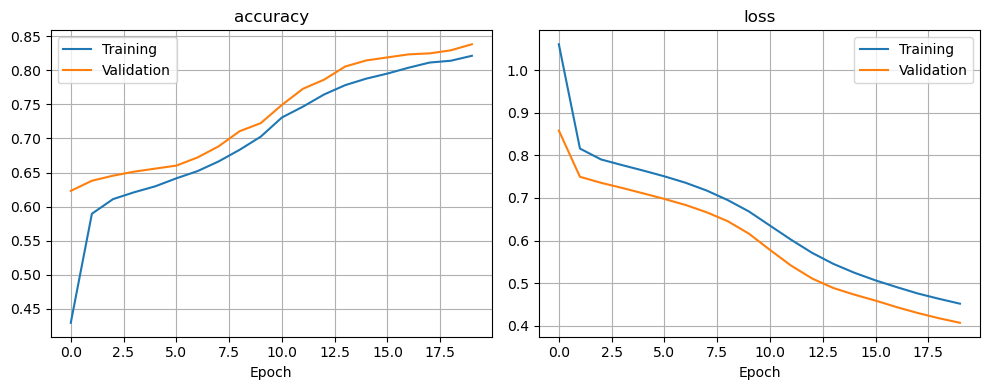

In [ ]:
utilities.plot_training_history(training_history_object_2, ['accuracy', 'loss'])

### Task 1.2.2 Evaluate on the test dataset
- Report test accuracy (and F1 score (f1_score() is in utilities.py)).

In [ ]:
# Make predictions
y_pred_2 = model2.predict(X_test)

print('Artificial neural network:')

# Calculate f1
f1_2 = utilities.f1_score(y_test, y_pred_2)
print(f'- Classification f1: {f1_2 * 100:.2f}%')

# Calculate accuracy
accuracy_2 = accuracy_score(y_test.argmax(axis=1), y_pred_2.argmax(axis=1))
print(f'- Classification Accuracy: {accuracy_2 * 100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Artificial neural network:
- Classification f1: 89.66%
- Classification Accuracy: 82.27%


### Task 1.2.3 Create a confusion matrix for both training and testing data
- Visualize confusion matrices.
- Do the test data and train data predict the same items wrong?

In [ ]:
conf_mat_train = sklearn.metrics.confusion_matrix(y_train.argmax(axis=1), model2.predict(X_train).argmax(axis=1))
train_instances = np.sum(conf_mat_train, axis=1)
# print(conf_mat_train)
# print(train_instances)

print("Scaled train confusion matrix")
print(np.transpose(conf_mat_train) / train_instances)



conf_mat_test = sklearn.metrics.confusion_matrix(y_test.argmax(axis=1), y_pred_2.argmax(axis=1))
test_instances = np.sum(conf_mat_test, axis=1)
print("\nScaled test confusion matrix")
print(np.transpose(conf_mat_test) / test_instances)


190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Scaled train confusion matrix
[[0.74391481 0.08610568 0.12072336]
 [0.09837728 0.8909002  0.02101662]
 [0.15770791 0.02299413 0.85826002]]

Scaled test confusion matrix
[[0.74828375 0.10759494 0.11020408]
 [0.1006865  0.86919831 0.0244898 ]
 [0.15102975 0.02320675 0.86530612]]


There are no obvious differences between the confusion matrices. This indicates that the model makes the same kind of prediction errors for both the training and test data.

## Part 2: Robustness (choose two or more), You may use add_gaussian_noise() and add_motion_blur() from utilities.py

### Task 2.1 Data Augmentation (training-time)
- Implement an augmentation pipeline.
- Train a model with augmentation and compare against the baseline from Part 1.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(width_shift_range=0.2,
                            height_shift_range=0.2,
                            zoom_range=0.2,
                            rotation_range=10,
                            vertical_flip=False,
                            horizontal_flip=False)
datagen.fit(X_train)
train_generator = datagen.flow(X_train, y_train,
                               batch_size=32)

In [ ]:
from tensorflow.keras.models import clone_model
model3 = clone_model(model2)

#model3.fit(train_generator, validation_data=(X_val, y_val), epochs=4, batch_size=32)

model3.summary()

optimizer = ks.optimizers.Adam()

# Compile model
model3.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )


filepath_model3 = "model3_best.weights.h5"
model_checkpoint_callback_3 = ks.callbacks.ModelCheckpoint(
        filepath=filepath_model3,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )

training_history_object_3 = model3.fit(train_generator,
          validation_data=(X_val, y_val),
          epochs=20,
          batch_size=64,
          callbacks = [model_checkpoint_callback_3]
          )

model3.load_weights(filepath_model3)

accuracy_3 = max(model3.history.history["val_accuracy"])
f1_score_3 = ks.backend.get_value(utilities.f1_score(y_val, model3.predict(X_val)))

print("\nModel 3:")
print(f"- Validation f1: {f1_score_3*100:.2f}%")
print(f"- Validation Accuracy: {accuracy_3*100:.2f}%")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 10)     │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 120)            │        43,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,231 (688.41 KB)

 Trainable params: 58,743 (229.46 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 117,488 (458.94 KB)

Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4805 - loss: 0.9953 - val_accuracy: 0.6395 - val_loss: 0.7734
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5876 - loss: 0.8406 - val_accuracy: 0.6409 - val_loss: 0.7704
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5868 - loss: 0.8192 - val_accuracy: 0.6469 - val_loss: 0.7264
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6104 - loss: 0.8035 - val_accuracy: 0.6217 - val_loss: 0.7305
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6320 - loss: 0.7911 - val_accuracy: 0.6766 - val_loss: 0.7161
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6478 - loss: 0.7765 - val_accuracy: 0.7033 - val_loss: 0.6982
Epoch 7/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6476 - loss: 0.7696 - val_accuracy: 0.7107 - val_loss: 0.6785
Epoch 8/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6653 - loss: 0.7500 - val_accu

In [ ]:
print('Model 2:')
print(f'- Classification f1: {f1_2 * 100:.2f}%')
print(f'- Classification Accuracy: {accuracy_2 * 100:.2f}%')


print('\nModel 3:')

# Make predictions
y_pred_3 = model3.predict(X_test)

# Calculate f1
f1_3 = utilities.f1_score(y_test, y_pred_3)
print(f'- Classification f1: {f1_3 * 100:.2f}%')

# Calculate accuracy
accuracy_3 = accuracy_score(y_test.argmax(axis=1), y_pred_3.argmax(axis=1))
print(f'- Classification Accuracy: {accuracy_3 * 100:.2f}%')


Model 2:
- Classification f1: 89.66%
- Classification Accuracy: 82.27%

Model 3:
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
- Classification f1: 90.81%
- Classification Accuracy: 83.82%


The augmented model performs minimally better.


### Task 2.2 Noise Robustness (test-time corruptions)
- Create corrupted versions of the test images and evaluate the baseline model:
  - Gaussian noise
  - Motion blur
- Report accuracy on the clean test set vs. each corrupted test set.


In [ ]:
X_test_gauss = utilities.add_gaussian_noise(X_test)
X_test_blur = utilities.add_motion_blur(X_test)


print('Model 2:')
print(f'- Classification f1: {f1_2 * 100:.2f}%')
print(f'- Classification Accuracy: {accuracy_2 * 100:.2f}%')


print('\nModel 2 (Gaussian noise):')
y_pred_2_gauss = model2.predict(X_test_gauss)
f1_2_gauss = utilities.f1_score(y_test, y_pred_2_gauss)
print(f'- Classification f1: {f1_2_gauss * 100:.2f}%')
accuracy_2_gauss = accuracy_score(y_test.argmax(axis=1), y_pred_2_gauss.argmax(axis=1))
print(f'- Classification Accuracy: {accuracy_2_gauss * 100:.2f}%')

print('\nModel 2 (Motion blur):')
y_pred_2_blur = model2.predict(X_test_blur)
f1_2_blur = utilities.f1_score(y_test, y_pred_2_blur)
print(f'- Classification f1: {f1_2_blur * 100:.2f}%')
accuracy_2_blur = accuracy_score(y_test.argmax(axis=1), y_pred_2_blur.argmax(axis=1))
print(f'- Classification Accuracy: {accuracy_2_blur * 100:.2f}%')


print('\n\nModel 3:')
print(f'- Classification f1: {f1_3 * 100:.2f}%')
print(f'- Classification Accuracy: {accuracy_3 * 100:.2f}%')


print('\nModel 3 (Gaussian noise):')
y_pred_3_gauss = model3.predict(X_test_gauss)
f1_3_gauss = utilities.f1_score(y_test, y_pred_3_gauss)
print(f'- Classification f1: {f1_3_gauss * 100:.2f}%')
accuracy_3_gauss = accuracy_score(y_test.argmax(axis=1), y_pred_3_gauss.argmax(axis=1))
print(f'- Classification Accuracy: {accuracy_3_gauss * 100:.2f}%')

print('\nModel 3 (Motion blur):')
y_pred_3_blur = model3.predict(X_test_blur)
f1_3_blur = utilities.f1_score(y_test, y_pred_3_blur)
print(f'- Classification f1: {f1_3_blur * 100:.2f}%')
accuracy_3_blur = accuracy_score(y_test.argmax(axis=1), y_pred_3_blur.argmax(axis=1))
print(f'- Classification Accuracy: {accuracy_3_blur * 100:.2f}%')

Model 2:
- Classification f1: 89.66%
- Classification Accuracy: 82.27%

Model 2 (Gaussian noise):
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
- Classification f1: 0.00%
- Classification Accuracy: 37.80%

Model 2 (Motion blur):
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
- Classification f1: 99.18%
- Classification Accuracy: 36.85%


Model 3:
- Classification f1: 90.81%
- Classification Accuracy: 83.82%

Model 3 (Gaussian noise):
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
- Classification f1: 0.00%
- Classification Accuracy: 37.80%

Model 3 (Motion blur):
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
- Classification f1: 98.56%
- Classification Accuracy: 44.64%


The accuracy on the corrupted datasets is close to random and much smaller than on the clean dataset for the baseline model. The augmented model performes much better on the motion blured dataset than the baseline model.


### Task 2.3  Discussion (no coding)
- Which noise types affect the model most?
- What techniques could improve robustness (data augmentation, adversarial training, denoising pre-processing, larger models)?

Motion blur seems to affect the model more than the gaussian noise.

Techniques like data augmentation, adversarial training and denoising pre-processing generally improve robustness.

# Part 3: Results & Comparison
- Summarize results (table/plot):
  - Baseline (clean) vs. Augmented (if attempted)
  - Clean vs. each corrupted test set (Task 2.2)
  


In [ ]:
from tabulate import tabulate

print("Accuracy of baseline- and augmented model:\n")

header = ["", "Baseline model", "Augmented model"]
left_column = ["Clean", "Gaussian noise", "Motion blur"]

data_table = [["Clean", accuracy_2, accuracy_3],
    ["Gaussian noise", accuracy_2_gauss, accuracy_3_gauss],
    ["Motion blur", accuracy_2_blur, accuracy_3_blur]]

data_table = [row[0:1]+[f"{el*100:.2f} %" for el in row if isinstance(el, float)] for row in data_table]

data_table_transpose = [[data_table[i][j] for i in range(len(data_table))] for j in range(len(data_table[0]))]

print(tabulate(
    data_table,
    headers=header,
    tablefmt="presto",
    colalign=("left", "center", "center")
    ))

Accuracy of baseline- and augmented model:

                |  Baseline model  |  Augmented model
----------------+------------------+-------------------
 Clean          |     82.27 %      |      83.82 %
 Gaussian noise |     37.80 %      |      37.80 %
 Motion blur    |     36.85 %      |      44.64 %


- Brief discussion:
  - Which corruptions hurt most, and why?
  - Did augmentation help? Which transforms mattered?
  - What would you try next (e.g., stronger augmentation, adversarial training, denoising pre-processing, larger models, early stopping, ensembling)?

The motion blur seems to hurt more than the gaussian noise. This is because the model uses a convolution layer, then a pooling layer at the start.

Augmentation helped with the motion blurred images. This is beacaus the augmentation we used shifted, zoomed and rotated the images. We essentially made the model more resilient to the type of transformations that happens in motion blurring.

We would try denoising pre-processing next, since our augmented model did not help against the data with gaussian noise.